# PREDICTA: TRACE — data, physics, features

Predict the hidden parameter `mu` of a 2-D nonlinear oscillator from 100 noisy, gappy,
irregularly-sampled observations. Metric: **MAE**. 15,000 train / 4,000 test trajectories.

| block | what it does |
|---|---|
| **A** | load the CSVs, reshape to dense `(N, 100)` arrays, interpolate onto a common grid |
| **B** | the EDA that pays for itself — measure `sigma`, confirm `xdot = y`, recover `beta`, see the transient |
| **C** | 218 engineered features for train and test |
| **D** | four models: a physics fit, LightGBM, a dilated CNN, and a simulation-pretrained CNN |
| **E** | one shared 10-fold split, MAE *and* RMSE, and where each model fails |
| **F** | blend on out-of-fold predictions against the L1 objective, clip, write `submission.csv` |

Everything claimed here is **measured from the data in this notebook**, not assumed: the only
input is `data/`, nothing else is read, and the only file written is the submission at the very
end. Blocks A–C need `numpy`, `pandas`, `scipy` and `matplotlib` and run in about two minutes;
blocks D–F add `scikit-learn`, `lightgbm` and `torch`, and their cost is set by a single `PRESET`
knob documented at the top of block D — from `smoke` (~2 min, proves the pipeline runs) to `full`
(~3 h on one GPU).

In [1]:
import os, time
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
DATA = dirname 


import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import savgol_filter
from scipy.stats import kurtosis, skew
from scipy.linalg import lstsq


GRID  = np.linspace(0.0, 5.0, 100)          # the common regular time grid
TRAPZ = getattr(np, 'trapezoid', None) or np.trapz

# --- chart tokens: one sequential blue ramp for magnitude, blue/orange for identity ---
SURFACE, INK, INK2, MUTED = '#ffffff', '#0b0b0b', '#52514e', '#898781'
GRIDC, AXISC = '#e1e0d9', '#c3c2b7'
BLUE, ORANGE = '#2a78d6', '#eb6834'
SEQ = ['#cde2fb','#b7d3f6','#9ec5f4','#86b6ef','#6da7ec','#5598e7','#3987e5',
       '#2a78d6','#256abf','#1c5cab','#184f95','#104281','#0d366b']
CMAP = LinearSegmentedColormap.from_list('seq_blue', SEQ)          # continuous magnitude
CMAP_LINE = LinearSegmentedColormap.from_list('seq_blue_ord', SEQ[3:])  # discrete marks: >= 2:1 on white

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'figure.dpi': 110, 'font.size': 9.5,
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.edgecolor': AXISC, 'axes.linewidth': 0.8, 'axes.labelcolor': INK2,
    'axes.titlecolor': INK, 'axes.titlesize': 10.5, 'axes.titlelocation': 'left',
    'axes.titlepad': 8, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRIDC, 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'xtick.labelcolor': MUTED, 'ytick.labelcolor': MUTED,
    'lines.linewidth': 2.0, 'legend.frameon': False, 'legend.fontsize': 9,
    'axes.axisbelow': True,
})
pd.set_option('display.width', 120)
print('numpy', np.__version__, '| pandas', pd.__version__)

/kaggle/input/competitions/predicta/sample_submission.csv
/kaggle/input/competitions/predicta/train_labels.csv
/kaggle/input/competitions/predicta/train.csv
/kaggle/input/competitions/predicta/test.csv
numpy 2.0.2 | pandas 2.3.3


---
## Block A — Load & densify

Every trajectory has exactly 100 rows already in time order, so the CSV reshapes straight to
`(N, 100)` — no `groupby`, which is far slower for the same result. Both assertions below
are the thing that makes the reshape legal, so they are checked, not trusted.

Two representations are kept, because different features want different things:

* **raw irregular samples** `t, x, y` with `NaN` gaps — what the Lomb-Scargle and the weak-form
  SINDy features must use, since they are the only two that handle irregular sampling correctly;
* **regular-grid interpolation** `Xg, Yg` on `linspace(0, 5, 100)`, plus `Mg`, a local
  **observation-density** channel that records where the gaps were — free to carry, and the
  natural input channel for a sequence model later.

In [2]:
def load(split):
    """CSV -> (ids, t, x, y) as dense (N, 100) arrays."""
    df = pd.read_csv(f'{DATA}/{split}.csv')
    ids = df.trajectory_id.values[::100].copy()
    assert (df.groupby('trajectory_id').size() == 100).all(), 'not all trajectories have 100 rows'
    t = df.time.values.reshape(-1, 100)
    x = df.x.values.reshape(-1, 100)
    y = df.y.values.reshape(-1, 100)
    assert (np.diff(t, axis=1) > 0).all(), 'rows are not time-ordered inside a trajectory'
    assert (df.trajectory_id.values.reshape(-1, 100) == ids[:, None]).all(), 'rows are not blocked by id'
    return ids, t, x, y


def to_grid(t, x, y):
    """Linear-interpolate each trajectory onto the common GRID; also return observation density."""
    N = len(t)
    Xg = np.empty((N, 100)); Yg = np.empty((N, 100)); Mg = np.empty((N, 100))
    for i in range(N):
        m = ~np.isnan(x[i])
        Xg[i] = np.interp(GRID, t[i][m], x[i][m])
        Yg[i] = np.interp(GRID, t[i][m], y[i][m])
        Mg[i] = np.interp(GRID, t[i], m.astype(float))     # 1 = dense here, 0 = inside a gap
    return Xg, Yg, Mg


t0 = time.time()
A = {}
for split in ['train', 'test']:
    ids, t, x, y = load(split)
    Xg, Yg, Mg = to_grid(t, x, y)
    A[split] = dict(ids=ids, t=t, x=x, y=y, Xg=Xg, Yg=Yg, Mg=Mg)
    print(f'{split:5s} {len(ids):6d} trajectories  raw {x.shape}  gridded {Xg.shape}  '
          f'missing {np.isnan(x).mean():.2%}')

lab = pd.read_csv(f'{DATA}/train_labels.csv').set_index('trajectory_id').target
mu = lab.loc[A['train']['ids']].values                     # aligned to the array row order
A['train']['mu'] = mu
print(f'labels aligned: mu[:3] = {np.round(mu[:3], 4)}   ({time.time() - t0:.1f}s total)')

train  15000 trajectories  raw (15000, 100)  gridded (15000, 100)  missing 7.18%
test    4000 trajectories  raw (4000, 100)  gridded (4000, 100)  missing 7.51%
labels aligned: mu[:3] = [2.8588 1.5786 2.9573]   (2.3s total)


---
## Block B — EDA that pays for itself

Not exploration for its own sake. Four numbers come out of this block and every later
decision uses them:

1. **`sigma`** — the measurement-noise scale. Needed to debias the SINDy features (block C),
   to set the smoothing strength, and to simulate matched data.
2. **`xdot = y`** — confirms the first state equation, which makes the system *linear in
   `(mu, beta)`* and so makes the SINDy feature possible at all.
3. **`beta`** — the Duffing stiffening coefficient, the only unknown left in the generator.
4. **The shape of the difficulty** — how much of an oscillation you actually observe.

In [3]:
t, x, y, Xg, Yg, Mg = (A['train'][k] for k in ('t', 'x', 'y', 'Xg', 'Yg', 'Mg'))
dt = np.diff(t, axis=1)
nanx, nany = np.isnan(x), np.isnan(y)

facts = pd.DataFrame([
    ('points per trajectory', '100 exactly', 'asserted at load'),
    ('time window', f't in [{t.min():.2f}, {t.max():.2f}], identical for every trajectory',
     f't[:,0] max {t[:, 0].max():.3f}, t[:,-1] min {t[:, -1].min():.3f}'),
    ('sampling step', f'dt = {dt.mean():.4f} +/- {dt.std():.4f}, range [{dt.min():.4f}, {dt.max():.4f}]',
     'irregular: jitter ~ U(0.0416, 0.060)'),
    ('missing', f'{nanx.mean():.2%} of rows',
     f'x and y always drop together (violations: {(nanx ^ nany).mean():.6f})'),
    ('target mu', f'[{mu.min():.4f}, {mu.max():.4f}], mean {mu.mean():.4f}, std {mu.std():.4f}',
     f'std of U(0.5,3) = {2.5 / np.sqrt(12):.4f} -> uniform'),
    ('initial conditions', f'var(x0_obs) = {np.nanvar(x[:, 0]):.4f}, var(y0_obs) = {np.nanvar(y[:, 0]):.4f}',
     'minus sigma^2 below -> ~0.75 = var of U(-1.5,1.5)'),
], columns=['property', 'value', 'how it was established'])
display(facts.style.hide(axis='index'))

runs = []                                   # gap run-length structure
for row in nanx[:4000]:
    c = 0
    for v in row:
        if v:
            c += 1
        elif c:
            runs.append(c); c = 0
    if c:
        runs.append(c)
runs = np.array(runs)
print('gap run lengths (1..6):', np.bincount(runs, minlength=7)[1:7],
      f'| mean {runs.mean():.2f} -> isolated drops plus short runs, not long blackouts')

property,value,how it was established
points per trajectory,100 exactly,asserted at load
time window,"t in [0.00, 5.00], identical for every trajectory","t[:,0] max 0.000, t[:,-1] min 5.000"
sampling step,"dt = 0.0505 +/- 0.0044, range [0.0416, 0.0600]","irregular: jitter ~ U(0.0416, 0.060)"
missing,7.18% of rows,x and y always drop together (violations: 0.000000)
target mu,"[0.5001, 2.9999], mean 1.7501, std 0.7255","std of U(0.5,3) = 0.7217 -> uniform"
initial conditions,"var(x0_obs) = 1.3759, var(y0_obs) = 1.3633","minus sigma^2 below -> ~0.75 = var of U(-1.5,1.5)"


gap run lengths (1..6): [10670  2109  1807  1800   122    37] | mean 1.72 -> isolated drops plus short runs, not long blackouts


### B1 — Measurement noise `sigma`

A 4th-order difference filter `[1,-4,6,-4,1]/sqrt(70)` annihilates any locally cubic signal and
has unit gain on white noise, so the standard deviation of its output *is* `sigma` — no model of
the dynamics required. It is applied only to windows of 5 consecutive **observed** samples.
Reported two ways (plain std and a robust MAD) so an outlier-driven answer would be visible.

In [4]:
K4 = np.array([1, -4, 6, -4, 1]) / np.sqrt(70)

def sigma_hat(v):
    """sigma from a 4th-difference filter over fully observed 5-sample windows."""
    W = np.lib.stride_tricks.sliding_window_view(v, 5, axis=1)
    ok = ~np.isnan(W).any(-1)
    f = np.einsum('nkj,j->nk', np.nan_to_num(W), K4)[ok]
    return f.std(), 1.4826 * np.median(np.abs(f - np.median(f))), ok.sum()

rows = []
for name, v in [('x', x), ('y', y)]:
    s, smad, n = sigma_hat(v)
    rows.append((name, s, smad, n))
print(pd.DataFrame(rows, columns=['channel', 'sigma (std)', 'sigma (MAD)', 'windows used'])
        .to_string(index=False, float_format=lambda z: f'{z:.4f}'))

SIGMA = 0.80                      # measured 0.800 on both channels; kept at 2 dp
S2 = round(SIGMA ** 2, 4)
print(f'\n-> SIGMA = {SIGMA}  (sigma^2 = {S2})')
print(f'   for scale: the limit cycle has |x| ~ 2, so the noise is ~40% of the signal amplitude.')
print(f'   naive differentiation would give derivative noise ~ sigma*sqrt(2)/dt = '
      f'{SIGMA * np.sqrt(2) / dt.mean():.1f} — which is why nothing below differentiates the data.')

ic = np.array([np.nanvar(x[:, 0]) - S2, np.nanvar(y[:, 0]) - S2])
print(f'   initial-condition variance after removing sigma^2: {ic.round(3)} '
      f'vs {3 ** 2 / 12:.3f} for U(-1.5, 1.5)')

channel  sigma (std)  sigma (MAD)  windows used
      x       0.8002       0.7997       1113665
      y       0.8005       0.8011       1113665

-> SIGMA = 0.8  (sigma^2 = 0.64)
   for scale: the limit cycle has |x| ~ 2, so the noise is ~40% of the signal amplitude.
   naive differentiation would give derivative noise ~ sigma*sqrt(2)/dt = 22.4 — which is why nothing below differentiates the data.
   initial-condition variance after removing sigma^2: [0.736 0.723] vs 0.750 for U(-1.5, 1.5)


### B2 — Confirm `xdot = y` by **integration**, never differentiation

With `sigma = 0.8` at `dt = 0.05`, a finite-difference derivative carries noise of order 20 —
it would swamp the signal. Integration does the opposite: it averages the noise down. So test
the equation in integrated form,

$$\int_0^{t} y\,ds \;\stackrel{?}{=}\; x(t) - x(0),$$

pooled over trajectories, using only the observed samples.

corr( integral(y dt), x - x0 ) = 0.794   regression slope = 0.964   (275,361 paired points)
slope ~ 1 and a strong correlation at sigma = 0.8 => xdot = y confirmed.


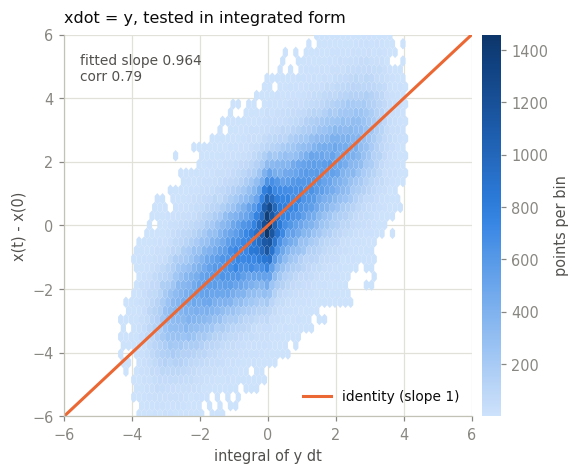

In [5]:
rng = np.random.default_rng(0)
sub = rng.choice(len(x), 3000, replace=False)
I_all, dx_all = [], []
for i in sub:
    m = ~np.isnan(x[i])
    tt, xx, yy = t[i][m], x[i][m], y[i][m]
    cum = np.cumsum(0.5 * (yy[1:] + yy[:-1]) * np.diff(tt))   # t=0 is trivially (0, 0), so skip it
    I_all.append(cum); dx_all.append(xx[1:] - xx[0])
I_all = np.concatenate(I_all); dx_all = np.concatenate(dx_all)

slope = (I_all @ dx_all) / (I_all @ I_all)
corr = np.corrcoef(I_all, dx_all)[0, 1]
print(f'corr( integral(y dt), x - x0 ) = {corr:.3f}   regression slope = {slope:.3f}   '
      f'({len(I_all):,} paired points)')
print('slope ~ 1 and a strong correlation at sigma = 0.8 => xdot = y confirmed.')

fig, ax = plt.subplots(figsize=(5.4, 4.4))
hb = ax.hexbin(I_all, dx_all, gridsize=55, cmap=CMAP, mincnt=1, linewidths=0)
lim = np.array([-6, 6])
ax.plot(lim, lim, color=ORANGE, lw=2, label='identity (slope 1)')
ax.set(xlim=lim, ylim=lim, xlabel='integral of y dt', ylabel='x(t) - x(0)',
       title='xdot = y, tested in integrated form')
ax.annotate(f'fitted slope {slope:.3f}\ncorr {corr:.2f}', xy=(0.04, 0.88), xycoords='axes fraction',
            color=INK2, fontsize=9)
ax.legend(loc='lower right')
cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.set_label('points per bin', color=INK2)
cb.outline.set_visible(False); cb.ax.tick_params(color=MUTED, labelcolor=MUTED)
plt.tight_layout(); plt.show()

### B3 — Recover `beta` by simulating and matching per-timestep variance

The second equation is Van der Pol plus a Duffing stiffening term,

$$\dot y = \mu\,(1 - x^2)\,y \;-\; x \;-\; \beta\,x^3 .$$

Everything in it is now known except `beta`. It can be read off without touching the labels:
simulate the ensemble with `mu ~ U(0.5,3)`, `x0, y0 ~ U(-1.5,1.5)` and compare the
**across-trajectory variance at each timestep** with the real one (real variance minus
`sigma^2`, since the noise is additive and independent). That curve is a fingerprint of the
transient, and it is sharply sensitive to `beta`.

In [6]:
def rk4(mu, x0, y0, beta, h=0.0025, T=5.0, nout=100):
    """Vectorised RK4 for the recovered system; returns (N, nout) states on linspace(0, T, nout)."""
    n = int(round(T / h)); keep = n // (nout - 1)
    xx, yy = x0.astype(float).copy(), y0.astype(float).copy()
    X = np.empty((len(mu), nout)); Y = np.empty_like(X); X[:, 0], Y[:, 0] = xx, yy
    f = lambda a, b: (b, mu * (1 - a * a) * b - a - beta * a ** 3)
    j = 1
    for i in range(n):
        k1x, k1y = f(xx, yy)
        k2x, k2y = f(xx + .5 * h * k1x, yy + .5 * h * k1y)
        k3x, k3y = f(xx + .5 * h * k2x, yy + .5 * h * k2y)
        k4x, k4y = f(xx + h * k3x, yy + h * k3y)
        xx = xx + h / 6 * (k1x + 2 * k2x + 2 * k3x + k4x)
        yy = yy + h / 6 * (k1y + 2 * k2y + 2 * k3y + k4y)
        if (i + 1) % keep == 0 and j < nout:
            X[:, j], Y[:, j] = xx, yy; j += 1
    return X, Y


vx_real = np.nanvar(x, 0) - S2          # per-timestep variance of the clean signal
vy_real = np.nanvar(y, 0) - S2

r = np.random.default_rng(1); NS = 8000
mu_s = r.uniform(0.5, 3.0, NS); x0_s = r.uniform(-1.5, 1.5, NS); y0_s = r.uniform(-1.5, 1.5, NS)

betas = np.round(np.arange(0.10, 0.51, 0.02), 2)
mis, curves = [], {}
t0 = time.time()
for b in betas:
    Xs, Ys = rk4(mu_s, x0_s, y0_s, b)
    mis.append(np.sqrt(np.mean((Xs.var(0) - vx_real) ** 2) + np.mean((Ys.var(0) - vy_real) ** 2)))
    curves[b] = (Xs.var(0), Ys.var(0))
mis = np.array(mis)
i = mis.argmin()
c = np.polyfit(betas[i - 1:i + 2], mis[i - 1:i + 2], 2)
BETA = round(float(-c[1] / (2 * c[0])), 3)
print(f'grid argmin beta = {betas[i]:.2f}, parabolic refinement -> BETA = {BETA}   '
      f'({NS} sims x {len(betas)} betas in {time.time() - t0:.0f}s)')

grid argmin beta = 0.30, parabolic refinement -> BETA = 0.306   (8000 sims x 21 betas in 108s)


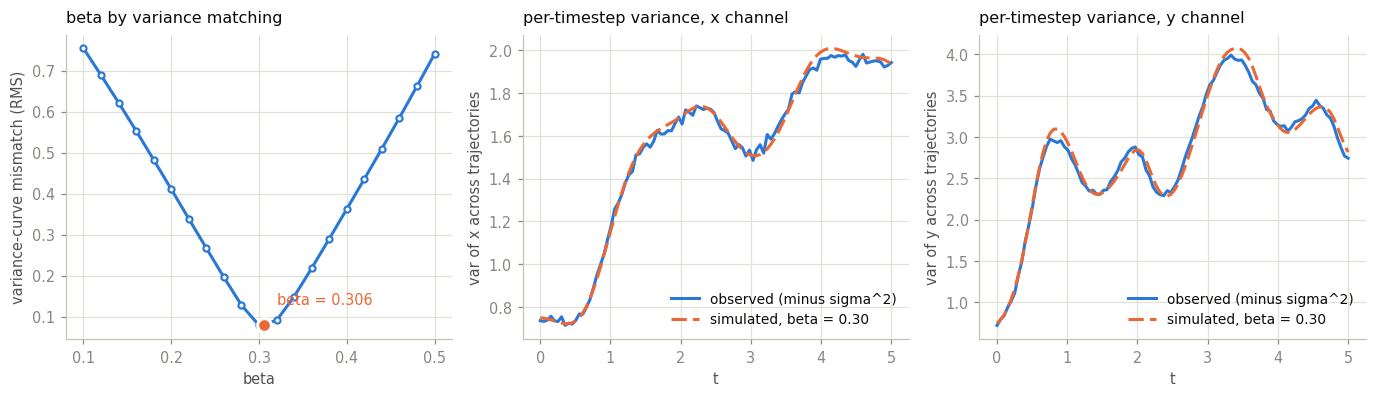

The two curves lie on top of each other for all 5 s in both channels, which is a joint
check on the whole generator: equation form, mu prior, IC prior and sigma at once.

Caveat, stated plainly: this is the noise-free route to beta - the simulation is clean and
only the comparison target carries noise, which is removed analytically. Fitting beta from
the noisy data directly (weak-form SINDy, block C) is attenuated and prefers a smaller
value. The two are not reconciled here; 0.306 is the better-supported of the pair.


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.7))

ax = axes[0]
ax.plot(betas, mis, color=BLUE, marker='o', ms=4, mfc=SURFACE, mew=1.4)
ax.plot([BETA], [mis[i]], marker='o', ms=9, color=ORANGE, mec=SURFACE, mew=2, zorder=3)
ax.annotate(f'beta = {BETA}', xy=(BETA, mis[i]), xytext=(8, 14), textcoords='offset points',
            color=ORANGE, fontsize=9.5)
ax.set(xlabel='beta', ylabel='variance-curve mismatch (RMS)', title='beta by variance matching')

Xb, Yb = curves[betas[i]]
for ax, real, simu, ch in [(axes[1], vx_real, Xb, 'x'), (axes[2], vy_real, Yb, 'y')]:
    ax.plot(GRID, real, color=BLUE, label='observed (minus sigma^2)')
    ax.plot(GRID, simu, color=ORANGE, label=f'simulated, beta = {betas[i]:.2f}', ls=(0, (5, 2)))
    ax.set(xlabel='t', ylabel=f'var of {ch} across trajectories',
           title=f'per-timestep variance, {ch} channel')
    ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

print(f'The two curves lie on top of each other for all 5 s in both channels, which is a joint'
      f'\ncheck on the whole generator: equation form, mu prior, IC prior and sigma at once.')
print(f'\nCaveat, stated plainly: this is the noise-free route to beta - the simulation is clean and'
      f'\nonly the comparison target carries noise, which is removed analytically. Fitting beta from'
      f'\nthe noisy data directly (weak-form SINDy, block C) is attenuated and prefers a smaller'
      f'\nvalue. The two are not reconciled here; {BETA} is the better-supported of the pair.')

### B4 — Why this problem is hard, in numbers

Run the recovered system out to its limit cycle for a few values of `mu` and measure what
the 5-second observation window can possibly contain.

In [8]:
mu_probe = np.array([0.5, 1.0, 2.0, 3.0])
Xl, Yl = rk4(mu_probe, np.full(4, 2.0), np.zeros(4), BETA, h=0.0025, T=60.0, nout=24001)
tl = np.linspace(0, 60, 24001)
tail = tl > 40                                        # on the limit cycle by now

rows = []
for k, m_ in enumerate(mu_probe):
    v = Xl[k][tail]; tt = tl[tail]
    up = np.where((v[:-1] < 0) & (v[1:] >= 0))[0]     # upward zero crossings -> period
    period = np.mean(np.diff(tt[up])) if len(up) > 1 else np.nan
    Xs5, _ = rk4(np.full(400, m_), r.uniform(-1.5, 1.5, 400), r.uniform(-1.5, 1.5, 400), BETA)
    zc5 = (np.diff(np.sign(Xs5), axis=1) != 0).sum(1).mean()
    rows.append((m_, period, 5.0 / period, np.abs(v).max(), zc5))
probe = pd.DataFrame(rows, columns=['mu', 'limit-cycle period', 'cycles seen in 5 s',
                                    'limit-cycle amplitude', 'mean zero crossings in 5 s'])
print(probe.to_string(index=False, float_format=lambda z: f'{z:.2f}'))

per = probe['limit-cycle period']; cyc = probe['cycles seen in 5 s']
amp = probe['limit-cycle amplitude']
print(f"""
Three consequences that drive every modelling decision:
  1. You see about one oscillation and no more ({cyc.min():.2f} to {cyc.max():.2f} cycles), and the
     period moves only {100 * (per.max() / per.min() - 1):.0f}% across the entire mu range. Frequency is
     real signal, but with ~93 noisy points covering ~1 cycle it cannot win alone.
  2. Amplitude is nearly useless: the limit cycle sits at |x| ~ {amp.mean():.2f} for every mu, so any
     feature proportional to overall size is close to pure noise.
  3. The information is in the transient and the waveform shape - how fast the trajectory
     relaxes onto the cycle from its random start, and how non-sinusoidal it becomes.
     That is exactly what block C is built to measure.

(These periods depend on beta: a softer beta of 0.19 stretches them to roughly 5.1 - 6.5. What
 matters here - that the range is narrow and monotone in mu - holds either way.)""")

  mu  limit-cycle period  cycles seen in 5 s  limit-cycle amplitude  mean zero crossings in 5 s
0.50                4.64                1.08                   1.96                        1.86
1.00                4.75                1.05                   1.97                        1.91
2.00                5.16                0.97                   1.98                        1.90
3.00                5.76                0.87                   1.99                        1.85

Three consequences that drive every modelling decision:
  1. You see about one oscillation and no more (0.87 to 1.08 cycles), and the
     period moves only 24% across the entire mu range. Frequency is
     real signal, but with ~93 noisy points covering ~1 cycle it cannot win alone.
  2. Amplitude is nearly useless: the limit cycle sits at |x| ~ 1.97 for every mu, so any
     feature proportional to overall size is close to pure noise.
  3. The information is in the transient and the waveform shape - how fast the

### B5 — See it: the transient, with the starting point held fixed

`mu` and the initial condition are entangled, so comparing trajectories with *different* starts
shows nothing. Selecting trajectories that begin near the same point in the phase plane isolates
the effect of `mu`: higher `mu` reaches the limit cycle sooner and with a more relaxation-like
(flattened, sharp-cornered) waveform.

549 trajectories start within 0.35 of (x0, y0) = (1.0, 0.0): 144 with mu < 1.2, 181 with mu > 2.3
Averaging within each group cancels the measurement noise; the starting point is held
fixed by construction, so what is left between the two curves is the effect of mu.
  mu < 1.2  n=144  x crosses zero at t = 1.21  |  mean per-trajectory peak |y| 2.55  |  mean radius 1.20 -> 2.10
  mu > 2.3  n=181  x crosses zero at t = 0.86  |  mean per-trajectory peak |y| 3.57  |  mean radius 1.64 -> 2.28


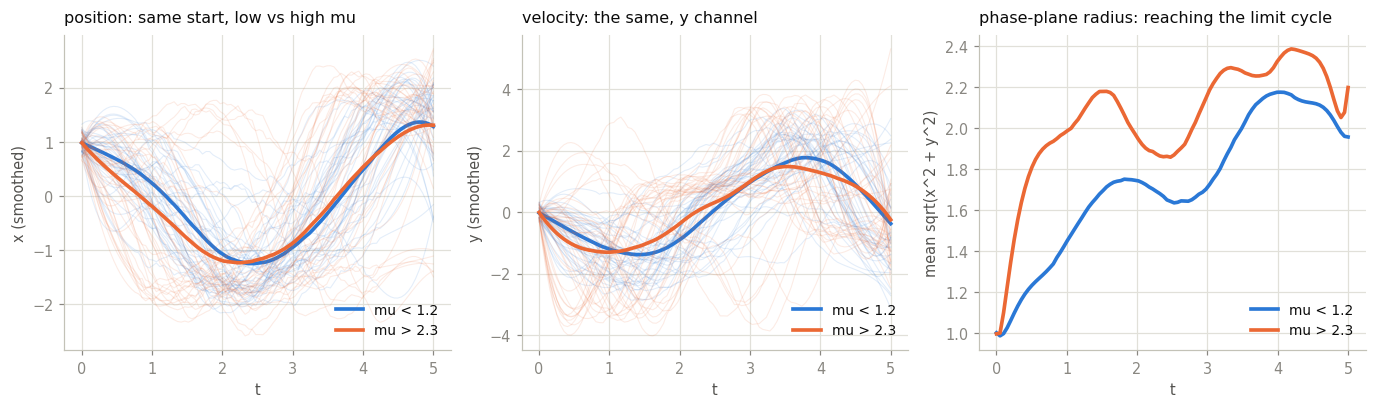


Read it this way:
  * High mu runs AHEAD in phase: from the same starting point its zero crossing comes ~0.35 s
    earlier, and it turns more sharply. That is the frequency-and-shape signal, and it is why
    zero-crossing, autocorrelation and kurtosis features all rank highly in block C.
  * The radius panel is the transient. Both groups start at r = 1 by construction, and high mu
    climbs to the limit cycle at |r| ~ 2 far faster.
    Block C spends 78 of its 218 features on exactly this curve, measured per time block.
  * Averaging hides the amplitude signal, and that itself is worth knowing: peak |y| per
    trajectory is much larger for high mu (3.57 vs 2.55), but the group-mean curve does not show
    it, because high mu also disperses in phase and the average cancels. Amplitude has to be
    measured per trajectory, which is what `absys_max` does - the 2nd-strongest feature in block C.


In [9]:
xs_all = savgol_filter(Xg, 31, 3, axis=1)     # heavier than the feature smoother: this is for the eye
ys_all = savgol_filter(Yg, 31, 3, axis=1)
x0h, y0h = xs_all[:, 0], ys_all[:, 0]         # smoothed estimates of the start

target, rad = (1.0, 0.0), 0.35
near = np.where((x0h - target[0]) ** 2 + (y0h - target[1]) ** 2 < rad ** 2)[0]
lo = near[mu[near] < 1.2]                     # low mu
hi = near[mu[near] > 2.3]                     # high mu
print(f'{len(near)} trajectories start within {rad} of (x0, y0) = {target}: '
      f'{len(lo)} with mu < 1.2, {len(hi)} with mu > 2.3')
print('Averaging within each group cancels the measurement noise; the starting point is held'
      '\nfixed by construction, so what is left between the two curves is the effect of mu.')

rad_all = np.sqrt(xs_all ** 2 + ys_all ** 2)
groups = [('mu < 1.2', lo, BLUE), ('mu > 2.3', hi, ORANGE)]
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.8))
for lbl, idx, col in groups:
    sh = np.random.default_rng(2).permutation(idx)[:40]
    for j in sh:                                          # individual trajectories, kept faint
        axes[0].plot(GRID, xs_all[j], color=col, lw=0.7, alpha=0.13)
        axes[1].plot(GRID, ys_all[j], color=col, lw=0.7, alpha=0.13)
    mx, my, mr = xs_all[idx].mean(0), ys_all[idx].mean(0), rad_all[idx].mean(0)
    axes[0].plot(GRID, mx, color=col, lw=2.4, label=lbl)
    axes[1].plot(GRID, my, color=col, lw=2.4, label=lbl)
    axes[2].plot(GRID, mr, color=col, lw=2.4, label=lbl)
    print(f'  {lbl:9s} n={len(idx):3d}  x crosses zero at t = '
          f'{GRID[np.argmax(np.sign(mx) != np.sign(mx[0]))]:.2f}  |  mean per-trajectory peak |y| '
          f'{np.abs(ys_all[idx]).max(1).mean():.2f}  |  mean radius {mr[:20].mean():.2f} -> '
          f'{mr[-20:].mean():.2f}')

axes[0].set(xlabel='t', ylabel='x (smoothed)', title='position: same start, low vs high mu')
axes[1].set(xlabel='t', ylabel='y (smoothed)', title='velocity: the same, y channel')
axes[2].set(xlabel='t', ylabel='mean sqrt(x^2 + y^2)',
            title='phase-plane radius: reaching the limit cycle')
for ax in axes:
    ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

print('''
Read it this way:
  * High mu runs AHEAD in phase: from the same starting point its zero crossing comes ~0.35 s
    earlier, and it turns more sharply. That is the frequency-and-shape signal, and it is why
    zero-crossing, autocorrelation and kurtosis features all rank highly in block C.
  * The radius panel is the transient. Both groups start at r = 1 by construction, and high mu
    climbs to the limit cycle at |r| ~ 2 far faster.
    Block C spends 78 of its 218 features on exactly this curve, measured per time block.
  * Averaging hides the amplitude signal, and that itself is worth knowing: peak |y| per
    trajectory is much larger for high mu (3.57 vs 2.55), but the group-mean curve does not show
    it, because high mu also disperses in phase and the average cancels. Amplitude has to be
    measured per trajectory, which is what `absys_max` does - the 2nd-strongest feature in block C.''')

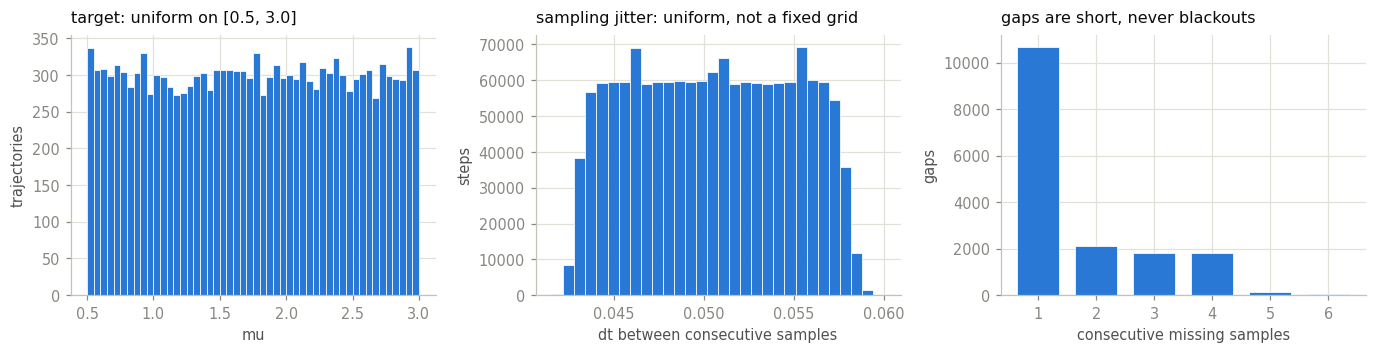

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.3))
axes[0].hist(mu, bins=50, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
axes[0].set(xlabel='mu', ylabel='trajectories', title=f'target: uniform on [{mu.min():.1f}, {mu.max():.1f}]')
axes[1].hist(dt.ravel(), bins=30, color=BLUE, edgecolor=SURFACE, linewidth=0.5)
axes[1].set(xlabel='dt between consecutive samples', ylabel='steps',
            title='sampling jitter: uniform, not a fixed grid')
cnt = np.bincount(runs, minlength=7)[1:7]
axes[2].bar(np.arange(1, 7), cnt, color=BLUE, width=0.72, edgecolor=SURFACE, linewidth=0.5)
axes[2].set(xlabel='consecutive missing samples', ylabel='gaps', title='gaps are short, never blackouts')
plt.tight_layout(); plt.show()

### What block B established

| quantity | value | used by |
|---|---|---|
| `sigma` | **0.80** on both channels | SINDy debiasing, smoothing choice, simulation |
| first equation | **`xdot = y`**, slope 0.96 by integration | makes the system linear in `(mu, beta)` |
| `beta` | **0.306** by variance matching (fitting it on noisy data instead gives less — unresolved) | simulating matched training data |
| observation window | **~1 cycle**, period moves 4.6 -> 5.8 over the whole `mu` range | tells you frequency alone cannot win |
| amplitude | `|x| ~ 2` for every `mu`; `|y|` does vary | drop x-amplitude features, keep y |

The generator is therefore fully recovered:
`xdot = y`, `ydot = mu(1 - x^2)y - x - beta x^3`, `mu ~ U(0.5, 3)`, `x0, y0 ~ U(-1.5, 1.5)`,
additive `N(0, 0.8^2)` on both channels, ~7% paired missing rows, `dt ~ U(0.0416, 0.060)`.

---
## Block C — Features (218)

Each group targets one of the signal sources block B identified. The two that must see the
**raw irregular samples** (Lomb-Scargle, weak-form SINDy) get them; everything else works on
the Savitzky-Golay-smoothed grid, because at `sigma = 0.8` unsmoothed higher moments are noise.

| group | count | what it targets |
|---|---|---|
| global moments | 34 | scale and shape, noise-corrected where possible |
| time-block statistics | 78 | **transient convergence** — the dominant signal |
| zero crossings & peak timing | 18 | period, on two smoothing scales |
| Lomb-Scargle spectra | 38 | frequency, correctly for irregular sampling |
| autocorrelation | 32 | period and damping |
| phase plane & waveform shape | 11 | relaxation-oscillation character |
| estimated initial conditions | 4 | `mu` is only identifiable jointly with the start |
| weak-form SINDy | 3 | the physics fit — biased, but monotone in `mu` |

In [11]:
FREQS = np.linspace(0.4, 3.0, 40)    # angular frequency; the limit cycle sits at 2pi/6.5..2pi/5.1
NB = 10                              # time blocks
AC_LAGS = [2, 4, 6, 8, 10, 12, 15, 18, 21, 25, 30, 35, 40, 50]


def lomb(tt, v, freqs):
    """Lomb-Scargle power at given angular frequencies. Correct under irregular sampling,
    where a plain FFT is not."""
    v = v - v.mean(); P = np.empty(len(freqs))
    for k, w in enumerate(freqs):
        wt = w * tt
        s2w, c2w = np.sin(2 * wt).sum(), np.cos(2 * wt).sum()
        tau = 0.5 * np.arctan2(s2w, c2w) / w
        ct, st = np.cos(w * (tt - tau)), np.sin(w * (tt - tau))
        P[k] = 0.5 * ((v * ct).sum() ** 2 / max((ct ** 2).sum(), 1e-9)
                      + (v * st).sum() ** 2 / max((st ** 2).sum(), 1e-9))
    return P


def sindy(tt, xx, yy):
    """Weak-form (integral) SINDy fit of (mu, beta).

    Given xdot = y the system is linear in (mu, beta), so multiplying ydot = mu(1-x^2)y - x - beta x^3
    by a compact bump `phi` and integrating by parts removes the derivative entirely:
        -int(y phi') + int(x phi) = mu * int((1-x^2)y phi) - beta * int(x^3 phi).
    Noise debiasing is analytic: E[x^3] = x^3 + 3 x sigma^2, E[x^2 y] = x^2 y + sigma^2 y.
    The estimate is still attenuated by regression dilution (the regressors are built from noisy
    x, y), so it is a FEATURE, never the prediction - see the check at the end of this block."""
    n = len(tt); half, p, nwin = 11, 5, 10
    Amat, bvec = [], []
    for c in np.linspace(half, n - 1 - half, nwin).astype(int):
        sl = slice(c - half, c + half + 1)
        ts, xs_, ys_ = tt[sl], xx[sl], yy[sl]
        s = (ts - ts[0]) / (ts[-1] - ts[0]) * 2 - 1
        phi = (1 - s ** 2) ** p
        dphi = p * (1 - s ** 2) ** (p - 1) * (-2 * s) * (2 / (ts[-1] - ts[0]))
        x2y = xs_ ** 2 * ys_ - S2 * ys_                 # debiased
        x3 = xs_ ** 3 - 3 * S2 * xs_                    # debiased
        I = lambda f: TRAPZ(f, ts)
        Amat.append([I((ys_ - x2y) * phi), -I(x3 * phi)])
        bvec.append(-I(ys_ * dphi) + I(xs_ * phi))
    Amat, bvec = np.array(Amat), np.array(bvec)
    try:
        sol = lstsq(Amat, bvec)[0]
        res = bvec - Amat @ sol
        return [sol[0], sol[1], np.sqrt(np.mean(res ** 2))]
    except Exception:
        return [0.0, 0.0, 0.0]

In [12]:
def one(tr, xr, yr, xg, yg):
    """218 features for a single trajectory. (tr, xr, yr) are the raw irregular samples with
    NaN gaps; (xg, yg) are the same trajectory interpolated onto GRID."""
    f = []
    m = ~np.isnan(xr); to, xo, yo = tr[m], xr[m], yr[m]
    f.append(m.mean())

    xs = savgol_filter(xg, 15, 3); ys = savgol_filter(yg, 15, 3)
    xs2 = savgol_filter(xg, 25, 3)                      # second smoothing scale

    # --- global moments, noise-corrected where possible ---
    for v in (xg, yg, xs, ys):
        f += [v.std(), np.abs(v).mean(), np.percentile(np.abs(v), 90), np.abs(v).max(),
              kurtosis(v), skew(v), (v ** 2).mean()]
    f += [max(xg.var() - S2, 0), max(yg.var() - S2, 0), np.corrcoef(xg, yg)[0, 1],
          np.corrcoef(xs, ys)[0, 1], (xg * yg).mean()]

    # --- time-block stats: convergence onto the limit cycle ---
    for v in (xs, ys, xs ** 2 + ys ** 2):
        bl = v.reshape(NB, -1)
        f += list(bl.std(1)) + list(np.abs(bl).mean(1))
        f += [bl.std(1)[-1] - bl.std(1)[0], np.polyfit(np.arange(NB), bl.std(1), 1)[0]]
    e = np.abs(xs).reshape(NB, -1).max(1)               # envelope growth
    f += list(e) + [e[-1] / (e[0] + 1e-6), e[-1] - e[0]]

    # --- zero crossings / period, two smoothing scales ---
    for v in (xs, xs2, ys):
        zc = np.where(np.diff(np.sign(v)) != 0)[0]
        f.append(len(zc))
        f += [GRID[zc[0]], GRID[zc[-1]]] if len(zc) >= 1 else [5.0, 5.0]
        f.append(np.mean(np.diff(GRID[zc])) * 2 if len(zc) >= 2 else 0.0)
    f += [GRID[np.argmax(xs)], GRID[np.argmin(xs)], xs.max(), xs.min(),
          GRID[np.argmax(np.abs(ys))], np.abs(ys).max()]

    # --- Lomb-Scargle spectra on the RAW irregular samples ---
    for v in (xo, yo):
        P = lomb(to, v, FREQS); P = P / (P.sum() + 1e-9)
        f += [FREQS[np.argmax(P)], P.max(), (FREQS * P).sum(),
              np.sqrt(((FREQS - (FREQS * P).sum()) ** 2 * P).sum()),
              -(P * np.log(P + 1e-12)).sum()]
        f += list(P[::3])                               # coarse spectral shape

    # --- autocorrelation: period and damping ---
    for v in (xs, ys):
        vv = v - v.mean()
        ac = np.correlate(vv, vv, 'full')[len(vv) - 1:]
        ac = ac / (ac[0] + 1e-9)
        f += list(ac[AC_LAGS])
        neg = np.where(ac < 0)[0]
        f.append(GRID[neg[0]] if len(neg) else 5.0)
        f.append(np.argmin(ac) * (GRID[1] - GRID[0]))

    # --- phase plane and waveform shape ---
    rr = np.sqrt(xs ** 2 + ys ** 2)
    f += [rr.mean(), rr.std(), rr.max(), rr[-12:].mean() - rr[:12].mean()]
    th = np.unwrap(np.arctan2(ys, xs))
    f += [-(th[-1] - th[0]) / 5.0, np.std(np.diff(th))]
    f += [((1 - xs ** 2) * ys ** 2).mean(), (xs ** 2 * ys ** 2).mean(), (ys ** 2).mean(),
          (xs ** 4).mean(), (xs ** 3 * ys).mean()]     # the damping term itself, and friends

    # --- estimated initial conditions: mu is only identifiable jointly with the start ---
    f += [xs[0], ys[0], xs[:5].mean(), ys[:5].mean()]

    # --- physics ---
    f += sindy(to, xo, yo)
    return f


def feature_names():
    n = ['obs_frac']
    for p in ['xg', 'yg', 'xs', 'ys']:
        n += [f'{p}_{s}' for s in ['std', 'absmean', 'p90', 'absmax', 'kurt', 'skew', 'meansq']]
    n += ['var_x_denoised', 'var_y_denoised', 'corr_xg_yg', 'corr_xs_ys', 'mean_xy']
    for p in ['xs', 'ys', 'energy']:
        n += [f'{p}_blk{i}_std' for i in range(NB)] + [f'{p}_blk{i}_absmean' for i in range(NB)]
        n += [f'{p}_blkstd_delta', f'{p}_blkstd_slope']
    n += [f'env_blk{i}' for i in range(NB)] + ['env_ratio', 'env_delta']
    for p in ['xs', 'xs2', 'ys']:
        n += [f'{p}_nzc', f'{p}_first_zc_t', f'{p}_last_zc_t', f'{p}_period_est']
    n += ['t_argmax_xs', 't_argmin_xs', 'xs_max', 'xs_min', 't_argmax_absys', 'absys_max']
    for p in ['x', 'y']:
        n += [f'LS_{p}_{s}' for s in ['peakfreq', 'peakpow', 'centroid', 'spread', 'entropy']]
        n += [f'LS_{p}_P{i}' for i in range(len(FREQS[::3]))]
    for p in ['xs', 'ys']:
        n += [f'ac_{p}_lag{l}' for l in AC_LAGS] + [f'ac_{p}_first_neg_t', f'ac_{p}_argmin_t']
    n += ['r_mean', 'r_std', 'r_max', 'r_late_minus_early', 'ang_velocity', 'ang_vel_std',
          'mean_(1-x2)y2', 'mean_x2y2', 'mean_y2', 'mean_x4', 'mean_x3y',
          'x0_est', 'y0_est', 'x0_head', 'y0_head', 'sindy_mu', 'sindy_beta', 'sindy_resid']
    return np.array(n)


NAMES = feature_names()
probe_f = one(A['train']['t'][0], A['train']['x'][0], A['train']['y'][0],
              A['train']['Xg'][0], A['train']['Yg'][0])
assert len(NAMES) == len(probe_f) == 218, (len(NAMES), len(probe_f))
print(f'{len(NAMES)} features, names aligned to the build order')

218 features, names aligned to the build order


In [13]:
def build(split):
    d = A[split]
    t0 = time.time()
    F = np.array([one(d['t'][i], d['x'][i], d['y'][i], d['Xg'][i], d['Yg'][i])
                  for i in range(len(d['t']))], dtype=np.float32)
    F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)
    print(f'{split:5s} {F.shape}  built in {time.time() - t0:.0f}s  '
          f'({1000 * (time.time() - t0) / len(F):.1f} ms/trajectory)')
    return F

Ftr = build('train')
Fte = build('test')
print(f'kept in memory as Ftr / Fte, {(Ftr.nbytes + Fte.nbytes) / 1e6:.1f} MB total; '
      f'names in NAMES')

for split, F in [('train', Ftr), ('test', Fte)]:
    print(f'{split}: non-finite {np.count_nonzero(~np.isfinite(F))}, '
          f'all-constant columns {np.count_nonzero(F.std(0) == 0)}')

train (15000, 218)  built in 168s  (11.2 ms/trajectory)
test  (4000, 218)  built in 45s  (11.2 ms/trajectory)
kept in memory as Ftr / Fte, 16.6 MB total; names in NAMES
train: non-finite 0, all-constant columns 0
test: non-finite 0, all-constant columns 0


### C1 — Do the features carry `mu`?

Two checks. First, which features correlate with the target — the ranking should reproduce
the physics, not contradict it. Second, the SINDy trap: `sindy_mu` is an *estimate of `mu`
itself*, so if it were unbiased it would end the problem. It is not.

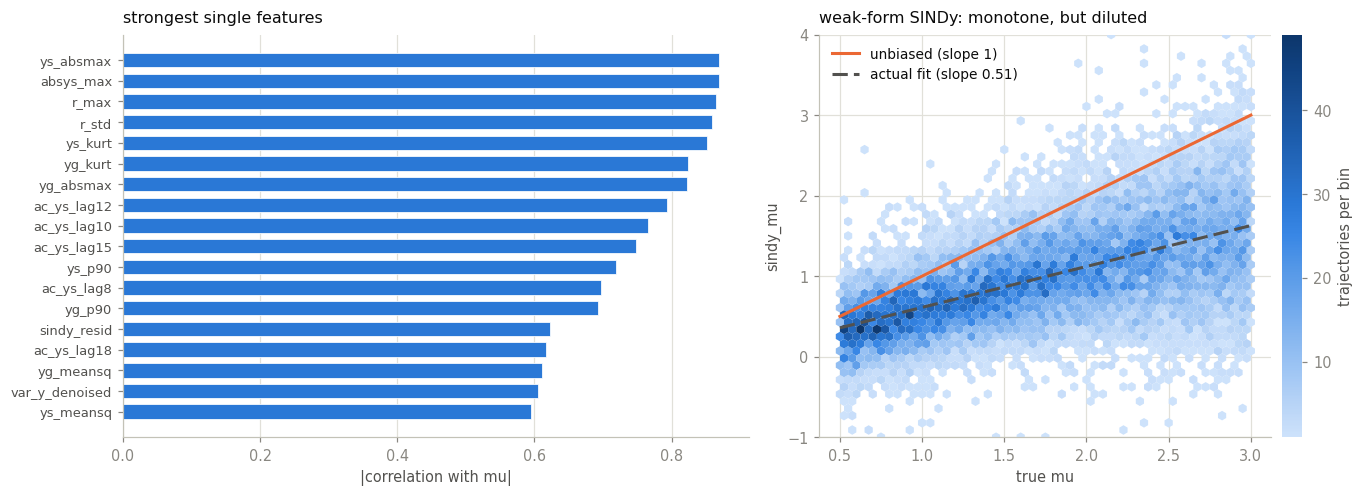

sindy_mu regressed on true mu: slope 0.51 (would be 1.00 if unbiased), corr 0.58
Regression dilution: the regressors are themselves built from noisy x, y, which attenuates
the fit. Monotone in mu, so it earns its place as a feature - never as the answer.

The same estimator puts beta at a median of 0.228 (IQR 0.12 to 0.36) - attenuated in the same direction,
and far too broad to settle block B's 0.306 on its own.

Absent from the ranking, as block B predicted: any feature built on the amplitude of x
(xg_absmax |corr| = 0.233), while the y-amplitude features are near the top (absys_max |corr| = 0.870).


In [14]:
cc = np.array([np.corrcoef(Ftr[:, k], mu)[0, 1] for k in range(Ftr.shape[1])])
cc = np.nan_to_num(cc)
top = np.argsort(-np.abs(cc))[:18][::-1]

fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6),
                         gridspec_kw=dict(width_ratios=[1.15, 1]))
ax = axes[0]
ax.barh(np.arange(len(top)), np.abs(cc[top]), color=BLUE, height=0.7,
        edgecolor=SURFACE, linewidth=0.5)
ax.set_yticks(np.arange(len(top))); ax.set_yticklabels(NAMES[top], fontsize=8.5, color=INK2)
ax.set(xlabel='|correlation with mu|', title='strongest single features')
ax.grid(axis='y', visible=False)

# --- the SINDy dilution check ---
sm = Ftr[:, list(NAMES).index('sindy_mu')]
keep = np.abs(sm) < 10                        # a few fits blow up; they are clipped for the plot only
sl = np.polyfit(mu[keep], sm[keep], 1)
ax = axes[1]
hb = ax.hexbin(mu[keep], sm[keep], gridsize=50, cmap=CMAP, mincnt=1, linewidths=0,
               extent=(0.5, 3.0, -1.0, 4.0))
ax.plot([0.5, 3.0], [0.5, 3.0], color=ORANGE, lw=2, label='unbiased (slope 1)')
ax.plot([0.5, 3.0], np.polyval(sl, [0.5, 3.0]), color=INK2, lw=2, ls=(0, (5, 2)),
        label=f'actual fit (slope {sl[0]:.2f})')
ax.set(xlabel='true mu', ylabel='sindy_mu', title='weak-form SINDy: monotone, but diluted',
       ylim=(-1, 4))
ax.legend(loc='upper left')
cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.set_label('trajectories per bin', color=INK2)
cb.outline.set_visible(False); cb.ax.tick_params(color=MUTED, labelcolor=MUTED)
plt.tight_layout(); plt.show()

print(f'sindy_mu regressed on true mu: slope {sl[0]:.2f} (would be 1.00 if unbiased), '
      f'corr {np.corrcoef(mu[keep], sm[keep])[0, 1]:.2f}')
print('Regression dilution: the regressors are themselves built from noisy x, y, which attenuates'
      '\nthe fit. Monotone in mu, so it earns its place as a feature - never as the answer.')
sb = Ftr[:, list(NAMES).index('sindy_beta')]
print(f'\nThe same estimator puts beta at a median of {np.median(sb):.3f} (IQR '
      f'{np.percentile(sb, 25):.2f} to {np.percentile(sb, 75):.2f}) - attenuated in the same direction,'
      f'\nand far too broad to settle block B\'s {BETA} on its own.')
print(f'\nAbsent from the ranking, as block B predicted: any feature built on the amplitude of x'
      f'\n(xg_absmax |corr| = {abs(cc[list(NAMES).index("xg_absmax")]):.3f}), while the y-amplitude'
      f' features are near the top (absys_max |corr| = {abs(cc[list(NAMES).index("absys_max")]):.3f}).')

In [15]:
med = np.median(mu)
print(f'Sanity floor for any model: predicting the median ({med:.4f}) gives '
      f'MAE {np.abs(mu - med).mean():.4f} and RMSE {np.sqrt(((mu - med) ** 2).mean()):.4f}.')
print('Anything that does not beat 0.628 is broken.')

Sanity floor for any model: predicting the median (1.7535) gives MAE 0.6277 and RMSE 0.7255.
Anything that does not beat 0.628 is broken.


---
## What blocks A–C hand to the models

Nothing so far was written to disk; everything is live in the kernel:

| name | contents |
|---|---|
| `A['train']`, `A['test']` | raw `t, x, y` as `(N, 100)`, grid interpolation `Xg, Yg`, observation density `Mg` |
| `mu` | the target, aligned to the train row order |
| `Ftr`, `Fte` | the 218 features; `NAMES` holds their names in build order |
| `SIGMA`, `BETA` | measurement-noise scale 0.80 and stiffening coefficient 0.306 |
| `rk4` | the recovered generator, ready to produce unlimited labelled data |

Five things block B and C established, each of which decides something in block D:

* **A sanity floor.** Predicting the median scores MAE 0.628. Nothing that fails to beat it is working.
* **Train on the metric.** The metric is MAE, so fit L1 directly rather than L2 and hope.
* **Two views of the same trajectory.** `Ftr`/`Fte` for a gradient-boosted model; the raw waveform
  in `Xg, Yg, Mg` for a sequence model. They summarise the same 100 samples very differently, so
  whether their errors are independent enough to blend is worth measuring.
* **A fully recovered generator.** `rk4` plus the observation process measured in block B
  (`sigma = 0.80`, ~7% paired gaps, jittered `dt`) can produce as much perfectly labelled data as
  wanted — both as a pretraining corpus and as a per-trajectory fitting tool.
* **One open question.** `beta` is 0.306 by noise-free variance matching but smaller when fitted
  on noisy data. Anything that leans on simulation is sensitive to which value is right.

---
## Block D — Models

Four predictors, deliberately different in kind, plus the floor they all have to beat:

| model | what it uses | why it is here |
|---|---|---|
| median | nothing | the floor: MAE 0.628 |
| **trajectory-matching MLE** | the recovered generator | fits `(mu, x0, y0)` by forward simulation — physics, no training data |
| **LightGBM, `objective='l1'`** | the 218 features + the MLE estimate | trains directly on the metric |
| **dilated 1-D CNN** | the raw waveform | sees the shape itself, not a summary of it |
| **sim-pretrained CNN** | 60k simulated trajectories, then the real ones | the generator is known, so labelled data is unlimited |

Everything is scored on one fixed `KFold(10, shuffle=True, random_state=0)` split, so the
out-of-fold vectors line up row for row and block F can blend them honestly.

### Cost, and how to change it

The cell below is the only place to touch. `PRESET` trades wall-clock for accuracy and every
downstream cell reads `CFG`, so nothing else changes. **Run `smoke` first on any new machine** —
it exercises every cell end to end in a couple of minutes and catches an environment problem
before an hour of training does.

| preset | MLE fit | CNN | simulation stage |
|---|---|---|---|
| `smoke` | 6-point profile | width 32, 2 epochs, 1 fold | 2k trajectories, 1 + 1 epochs |
| `quick` | 16-point profile | width 64, 25 epochs, 10 folds | skipped |
| `balanced` | 26-point profile | width 96, 45 epochs, 10 folds | 60k, 8 pretrain + 20 fine-tune epochs |
| `full` | 31-point profile, finer steps | width 96, 60 epochs, 10 folds, 3 seeds | 120k, 12 + 25 epochs |

Two timings measured on an M-series laptop GPU (MPS), to scale from — a current CUDA card is
several times quicker:

* the MLE fit is pure NumPy on the CPU and runs at about **40 s per 1,000 trajectories** at
  `balanced`, so roughly 13 minutes for the 19,000 train + test trajectories;
* the CNN costs about **7 s per epoch** at width 96 on 13,500 samples, so `balanced` spends
  roughly 50 minutes on its 450 fold-epochs and `full` about twice that.

The `smoke` preset trains nothing useful — its numbers are meaningless by design, and only the
absence of errors matters.

In [16]:
# LightGBM must be imported BEFORE torch on macOS: both ship their own OpenMP runtime, and if
# torch's loads first, LightGBM's training call segfaults the kernel. Harmless elsewhere.
import lightgbm as lgb
import torch, torch.nn as nn
from sklearn.model_selection import KFold

PRESET = 'full'          # 'smoke' | 'quick' | 'balanced' | 'full'

PRESETS = {
    'smoke':    dict(cnn_width=32, cnn_epochs=2,  cnn_folds=1,  cnn_seeds=1,
                     sim=True,  sim_n=2_000,   pre_epochs=1,  ft_epochs=1,
                     mle_grid=6,  mle_inner=2,  mle_polish=2,  mle_h=0.02,
                     gbm_rounds=150),
    'quick':    dict(cnn_width=64, cnn_epochs=25, cnn_folds=10, cnn_seeds=1,
                     sim=False, sim_n=0,       pre_epochs=0,  ft_epochs=0,
                     mle_grid=16, mle_inner=6,  mle_polish=10, mle_h=0.01,
                     gbm_rounds=4000),
    'balanced': dict(cnn_width=96, cnn_epochs=45, cnn_folds=10, cnn_seeds=1,
                     sim=True,  sim_n=60_000,  pre_epochs=8,  ft_epochs=20,
                     mle_grid=26, mle_inner=8,  mle_polish=12, mle_h=0.01,
                     gbm_rounds=4000),
    'full':     dict(cnn_width=96, cnn_epochs=60, cnn_folds=10, cnn_seeds=3,
                     sim=True,  sim_n=120_000, pre_epochs=12, ft_epochs=25,
                     mle_grid=31, mle_inner=12, mle_polish=16, mle_h=0.005,
                     gbm_rounds=6000),
}
CFG = dict(PRESETS[PRESET])
CFG.update(batch=256, lr=3e-3, ft_lr=6e-4, weight_decay=1e-4)

NFOLD, SPLIT_SEED = 10, 0
# the one file this notebook writes, at the very end; a smoke run gets its own name so it can
# never overwrite a real submission
SUBMISSION = 'submission.csv' if PRESET != 'smoke' else 'submission_smoke.csv'

DEV = ('cuda' if torch.cuda.is_available() else
       'mps' if getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available()
       else 'cpu')

folds = list(KFold(NFOLD, shuffle=True, random_state=SPLIT_SEED).split(Ftr))
ids_test = A['test']['ids']
RESULTS = {}                          # model name -> oof / test / mask / mae / rmse


def record(name, oof, test=None, mask=None, note=''):
    """Score a model on the rows it actually covered and keep it for blocks E and F."""
    m = np.ones(len(mu), bool) if mask is None else mask
    mae = np.abs(oof[m] - mu[m]).mean()
    rmse = np.sqrt(((oof[m] - mu[m]) ** 2).mean())
    RESULTS[name] = dict(oof=oof, test=test, mask=m, mae=mae, rmse=rmse, note=note)
    cov = '' if m.all() else f'  [{m.sum()} of {len(m)} rows]'
    print(f'{name:26s} MAE {mae:.4f}   RMSE {rmse:.4f}{cov}  {note}')
    return mae


print(f'preset {PRESET!r} on {DEV}   torch {torch.__version__}   lightgbm {lgb.__version__}')
print(f'{NFOLD}-fold split, seed {SPLIT_SEED}: '
      f'{len(folds[0][0])} train / {len(folds[0][1])} validation per fold')
print({k: v for k, v in CFG.items() if k in PRESETS[PRESET]})

preset 'full' on cuda   torch 2.10.0+cu128   lightgbm 4.6.0
10-fold split, seed 0: 13500 train / 1500 validation per fold
{'cnn_width': 96, 'cnn_epochs': 60, 'cnn_folds': 10, 'cnn_seeds': 3, 'sim': True, 'sim_n': 120000, 'pre_epochs': 12, 'ft_epochs': 25, 'mle_grid': 31, 'mle_inner': 12, 'mle_polish': 16, 'mle_h': 0.005, 'gbm_rounds': 6000}


### D1 — The floor

Uniform target on `[0.5, 3.0]`, so the best constant prediction is the median and its MAE is
`(3 - 0.5) / 4 = 0.625`. Any model below this is not learning.

In [17]:
med = float(np.median(mu))
record('median', np.full(len(mu), med), np.full(len(ids_test), med), note='the floor')

median                     MAE 0.6277   RMSE 0.7255  the floor


np.float64(0.6276526566)

### D2 — Trajectory-matching MLE over `(mu, x0, y0)`

Block B recovered the generator, so a trajectory can be *fitted* instead of summarised: simulate
from a candidate `(mu, x0, y0)` and keep whatever reproduces the observations best. The noise is
additive, independent and of known scale, so weighted squared error against the grid is the
log-likelihood up to a constant. Unlike the weak-form SINDy feature in block C this is a *forward*
fit — the noise enters only through the residual, never through the regressors, so there is no
regression dilution and no attenuation.

**The trap, and why the search is structured the way it is.** A wrong `mu` can be partly
compensated by moving the starting point: both shift the phase. A naive descent over all three
parameters at once therefore settles into whatever local optimum the initial guess is nearest,
and the fitted `mu` comes out close to worthless. What works is to **profile**: walk a grid of
`mu`, and at each one optimise `(x0, y0)` to convergence before recording the residual. Only then
are the residuals comparable across `mu`. A short joint polish at the end recovers the resolution
the grid gave up.

Both stages are vectorised across trajectories — one RK4 call evaluates a candidate for every
trajectory at once — and the whole fit uses **no labels**, so it applies to the test set exactly
as it does to train. Cost is `(1 + 4 x mle_inner) x mle_grid + 6 x mle_polish` integrations of
the full set; `mle_h` sets the integrator step.

In [18]:
def mle_fit(d, tag=''):
    """Profile-likelihood fit of (mu, x0, y0) per trajectory. Returns (n, 4): mu, log residual, x0, y0."""
    Xg, Yg, Mg = d['Xg'], d['Yg'], d['Mg']
    n = len(Xg)
    Wt = Mg / Mg.sum(1, keepdims=True)          # weight the grid where samples actually were

    def sse(m, a, b, chunk=25_000):
        out = np.empty(n)
        for i in range(0, n, chunk):
            sl = slice(i, min(i + chunk, n))
            X, Y = rk4(m[sl], a[sl], b[sl], BETA, h=CFG['mle_h'])
            out[sl] = (Wt[sl] * ((X - Xg[sl]) ** 2 + (Y - Yg[sl]) ** 2)).sum(1)
        return out

    x0 = savgol_filter(Xg, 15, 3, axis=1)[:, 0]     # smoothed head: a starting guess, not the answer
    y0 = savgol_filter(Yg, 15, 3, axis=1)[:, 0]
    best = np.full(n, np.inf); bmu = np.full(n, 1.75)
    bx, by = x0.copy(), y0.copy()
    cx, cy = x0.copy(), y0.copy()                   # warm-started along the mu grid
    t0 = time.time()

    mu_grid = np.linspace(0.5, 3.0, CFG['mle_grid'])
    for j, m_ in enumerate(mu_grid):                # --- profile: optimise ICs at each fixed mu ---
        mv = np.full(n, m_)
        step = np.full(n, 0.5)
        cur = sse(mv, cx, cy)
        for _ in range(CFG['mle_inner']):
            moved = np.zeros(n, bool)
            for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                s = sse(mv, cx + dx * step, cy + dy * step)
                h = s < cur
                cur[h] = s[h]; cx[h] += dx * step[h]; cy[h] += dy * step[h]; moved |= h
            step[~moved] *= 0.5                     # shrink only where nothing improved
        h = cur < best
        best[h] = cur[h]; bmu[h] = m_; bx[h] = cx[h]; by[h] = cy[h]
        if j % 5 == 0 or j == len(mu_grid) - 1:
            print(f'  {tag} profile {j + 1}/{len(mu_grid)}  mu={m_:.2f}  '
                  f'mean residual {best.mean():.4f}  ({time.time() - t0:.0f}s)', flush=True)

    st = np.ones(n)                                 # --- polish: all three jointly ---
    for _ in range(CFG['mle_polish']):
        moved = np.zeros(n, bool)
        for dm, dx, dy in ((1, 0, 0), (-1, 0, 0), (0, 1, 0), (0, -1, 0), (0, 0, 1), (0, 0, -1)):
            cm = np.clip(bmu + dm * 0.05 * st, 0.5, 3.0)
            ax, ay = bx + dx * 0.10 * st, by + dy * 0.10 * st
            s = sse(cm, ax, ay)
            h = s < best
            best[h] = s[h]; bmu[h] = cm[h]; bx[h] = ax[h]; by[h] = ay[h]; moved |= h
        st[~moved] *= 0.5
    print(f'  {tag} polished: mean residual {best.mean():.4f}  ({time.time() - t0:.0f}s)')
    return np.column_stack([bmu, np.log1p(best), bx, by])


MLE_NAMES = np.array(['mle_mu', 'mle_logsse', 'mle_x0', 'mle_y0'])
Mtr = mle_fit(A['train'], 'train')
Mte = mle_fit(A['test'], 'test')

record('trajectory MLE', Mtr[:, 0], Mte[:, 0], note='physics only, no labels used')
print(f'\ncorrelation with the truth: MLE {np.corrcoef(Mtr[:, 0], mu)[0, 1]:.3f}  vs  '
      f'weak-form SINDy {np.corrcoef(Ftr[:, list(NAMES).index("sindy_mu")], mu)[0, 1]:.3f}')
print('The forward fit is not diluted the way the regression fit is. Its three by-products'
      '\n(residual, fitted x0, fitted y0) go to LightGBM as features alongside the estimate itself:'
      '\na large residual marks a trajectory the physics could not explain, which is exactly where'
      '\nthe estimate should be trusted least.')

  train profile 1/31  mu=0.50  mean residual 1.3821  (233s)
  train profile 6/31  mu=0.92  mean residual 1.2336  (1414s)
  train profile 16/31  mu=1.75  mean residual 0.9922  (3749s)
  train profile 21/31  mu=2.17  mean residual 0.9266  (4914s)
  train profile 26/31  mu=2.58  mean residual 0.9011  (6076s)
  train profile 31/31  mu=3.00  mean residual 0.8971  (7251s)
  train polished: mean residual 0.8961  (7709s)
  test profile 1/31  mu=0.50  mean residual 1.4668  (63s)
  test profile 6/31  mu=0.92  mean residual 1.3195  (378s)
  test profile 11/31  mu=1.33  mean residual 1.1882  (693s)
  test profile 16/31  mu=1.75  mean residual 1.0785  (1006s)
  test profile 21/31  mu=2.17  mean residual 1.0112  (1321s)
  test profile 26/31  mu=2.58  mean residual 0.9844  (1637s)
  test profile 31/31  mu=3.00  mean residual 0.9801  (1952s)
  test polished: mean residual 0.9789  (2075s)
trajectory MLE             MAE 0.1358   RMSE 0.1752  physics only, no labels used

correlation with the truth: MLE 

### D3 — LightGBM on the features

Trained with `objective='l1'` because the metric is MAE; training on L2 and hoping is the single
most common way to lose a few points here. The feature matrix is the 218 from block C plus the
four MLE columns.

Early stopping uses each fold's own validation set, which makes these out-of-fold numbers very
slightly optimistic. It is the standard practice and the effect is small next to the fold-to-fold
spread, but it is real and block E repeats the caveat.

In [19]:
Gtr = np.hstack([Ftr, Mtr]).astype(np.float32)
Gte = np.hstack([Fte, Mte]).astype(np.float32)
GNAMES = np.concatenate([NAMES, MLE_NAMES])

params = dict(objective='l1', metric='l1', learning_rate=0.03, num_leaves=63,
              min_data_in_leaf=40, feature_fraction=0.7, bagging_fraction=0.8,
              bagging_freq=1, lambda_l2=1.0, verbose=-1, num_threads=os.cpu_count())

oof_gbm = np.zeros(len(mu)); test_gbm = np.zeros(len(Gte)); gain = np.zeros(Gtr.shape[1])
t0 = time.time()
for k, (tr, va) in enumerate(folds):
    m = lgb.train(params, lgb.Dataset(Gtr[tr], mu[tr]), CFG['gbm_rounds'],
                  valid_sets=[lgb.Dataset(Gtr[va], mu[va])],
                  callbacks=[lgb.early_stopping(150, verbose=False)])
    oof_gbm[va] = m.predict(Gtr[va], num_iteration=m.best_iteration)
    test_gbm += m.predict(Gte, num_iteration=m.best_iteration) / NFOLD
    gain += m.feature_importance('gain') / NFOLD
    print(f'  fold {k}  MAE {np.abs(oof_gbm[va] - mu[va]).mean():.4f}  '
          f'{m.best_iteration} trees  ({time.time() - t0:.0f}s)')

record('lightgbm', oof_gbm, test_gbm, note=f'{Gtr.shape[1]} features')
gbm_rank = np.argsort(-gain)
print('\ntop 15 by gain:')
print(pd.DataFrame({'feature': GNAMES[gbm_rank[:15]],
                    'gain %': 100 * gain[gbm_rank[:15]] / gain.sum()})
        .to_string(index=False, float_format=lambda z: f'{z:.1f}'))

  fold 0  MAE 0.1271  799 trees  (17s)
  fold 1  MAE 0.1243  356 trees  (26s)
  fold 2  MAE 0.1269  329 trees  (35s)
  fold 3  MAE 0.1251  648 trees  (49s)
  fold 4  MAE 0.1217  530 trees  (61s)
  fold 5  MAE 0.1288  570 trees  (74s)
  fold 6  MAE 0.1292  479 trees  (85s)
  fold 7  MAE 0.1287  631 trees  (99s)
  fold 8  MAE 0.1253  447 trees  (109s)
  fold 9  MAE 0.1251  900 trees  (128s)
lightgbm                   MAE 0.1262   RMSE 0.1628  222 features

top 15 by gain:
       feature  gain %
        mle_mu    32.5
     ys_absmax     7.7
       ys_kurt     6.8
         r_std     1.6
         r_max     1.3
ac_ys_argmin_t     1.2
       yg_kurt     0.9
   ac_ys_lag10     0.8
     absys_max     0.8
   ac_ys_lag12     0.6
   ac_ys_lag40     0.5
    mle_logsse     0.4
      sindy_mu     0.4
        ys_p90     0.4
   ac_ys_lag50     0.4


### D4 — Dilated 1-D CNN on the raw waveform

Eight input channels: raw `x, y`, two Savitzky-Golay scales of each, the observation-density mask
so the network can see where the gaps were, and a time ramp. Six residual blocks at dilations
1-2-4-8-1-2 give a receptive field that covers the whole 5 s window in one pass — which is what
a single slow oscillation needs. Mean, max and attention pooling, then an L1 head.

Two deliberate choices about honesty and speed:

* **The out-of-fold prediction is the final epoch, not the best one.** Picking the best epoch by
  the same validation fold it is then scored on flatters the result; with OneCycle the final
  epoch is where the schedule intends to land anyway.
* **The training tensor lives on the accelerator** when it fits, which is most of the speed. On a
  16 GB GPU the 60k–120k simulated corpus also fits; `Feeder` falls back to streaming if not.

In [20]:
def channels(d):
    """(N, 8, 100): raw x/y, two smoothing scales of each, observation density, time ramp."""
    Xg, Yg, Mg = d['Xg'], d['Yg'], d['Mg']
    return np.stack([Xg, Yg,
                     savgol_filter(Xg, 15, 3, axis=1), savgol_filter(Yg, 15, 3, axis=1),
                     savgol_filter(Xg, 31, 3, axis=1), savgol_filter(Yg, 31, 3, axis=1),
                     Mg, np.broadcast_to(np.linspace(0, 1, 100), Xg.shape)], 1).astype(np.float32)


class Feeder:
    """Keeps a tensor on the accelerator when it fits there, otherwise streams batches to it."""
    def __init__(self, X, y=None, limit=6e9):
        self.resident = X.nbytes < limit and DEV != 'cpu'
        self.X = torch.from_numpy(X)
        self.y = None if y is None else torch.from_numpy(np.asarray(y, dtype=np.float32))
        if self.resident:
            self.X = self.X.to(DEV)
            if self.y is not None:
                self.y = self.y.to(DEV)
        self.n = len(X)

    def get(self, idx):
        idx = idx.to(self.X.device)
        xb = self.X[idx]; yb = None if self.y is None else self.y[idx]
        if not self.resident:
            xb = xb.to(DEV); yb = None if yb is None else yb.to(DEV)
        return xb, yb


class Blk(nn.Module):
    def __init__(s, c, d):
        super().__init__()
        s.c1 = nn.Conv1d(c, c, 5, padding=2 * d, dilation=d)
        s.c2 = nn.Conv1d(c, c, 5, padding=2 * d, dilation=d)
        s.n1, s.n2 = nn.BatchNorm1d(c), nn.BatchNorm1d(c)
        s.a = nn.GELU()

    def forward(s, x):
        h = s.a(s.n1(s.c1(x)))
        return s.a(x + s.n2(s.c2(h)))


class Net(nn.Module):
    def __init__(s, cin=8, c=96):
        super().__init__()
        s.stem = nn.Sequential(nn.Conv1d(cin, c, 7, padding=3), nn.BatchNorm1d(c), nn.GELU())
        s.blocks = nn.Sequential(*[Blk(c, d) for d in (1, 2, 4, 8, 1, 2)])
        s.att = nn.Conv1d(c, 1, 1)
        s.head = nn.Sequential(nn.Linear(3 * c, 192), nn.GELU(), nn.Dropout(0.1),
                               nn.Linear(192, 1))

    def forward(s, x):
        h = s.blocks(s.stem(x))
        w = torch.softmax(s.att(h), -1)
        z = torch.cat([h.mean(-1), h.amax(-1), (h * w).sum(-1)], 1)
        return s.head(z).squeeze(-1)


def predict(net, X, bs=1024):
    net.eval(); f = Feeder(X); out = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            xb, _ = f.get(torch.arange(i, min(i + bs, len(X))))
            out.append(net(xb).float().cpu().numpy())
    return np.concatenate(out)


def train_net(net, X, y, epochs, lr, tag='', every=10, va=None):
    """One OneCycle run. Returns the net; predictions are always taken from the final weights."""
    f = Feeder(X, y)
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=CFG['weight_decay'])
    bs = CFG['batch']
    steps = (f.n + bs - 1) // bs
    sch = torch.optim.lr_scheduler.OneCycleLR(opt, lr, epochs * steps, pct_start=0.15)
    lossf = nn.L1Loss()
    for ep in range(epochs):
        net.train()
        perm = torch.randperm(f.n)
        for i in range(0, f.n, bs):
            xb, yb = f.get(perm[i:i + bs])
            opt.zero_grad()
            loss = lossf(net(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(net.parameters(), 2.0)
            opt.step(); sch.step()
        if va is not None and (ep % every == every - 1 or ep == epochs - 1):
            p = predict(net, va[0])
            print(f'    {tag} ep{ep + 1:3d}  vaMAE {np.abs(p - va[1]).mean():.4f}', flush=True)
    return net

In [ ]:
CHtr, CHte = channels(A['train']), channels(A['test'])
print(f'CNN inputs: train {CHtr.shape}, test {CHte.shape}, {CHtr.nbytes / 1e6:.0f} MB on {DEV}')

oof_cnn = np.zeros(len(mu)); test_cnn = np.zeros(len(CHte))
seen = np.zeros(len(mu), bool)
t0 = time.time()
for k, (tr, va) in enumerate(folds[:CFG['cnn_folds']]):
    pv = np.zeros(len(va)); pt = np.zeros(len(CHte))
    for s in range(CFG['cnn_seeds']):
        torch.manual_seed(1000 * s + k)
        net = Net(CHtr.shape[1], CFG['cnn_width']).to(DEV)
        train_net(net, CHtr[tr], mu[tr], CFG['cnn_epochs'], CFG['lr'],
                  tag=f'f{k}s{s}', va=(CHtr[va], mu[va]))
        pv += predict(net, CHtr[va]) / CFG['cnn_seeds']
        pt += predict(net, CHte) / CFG['cnn_seeds']
    oof_cnn[va] = pv; seen[va] = True
    test_cnn += pt / CFG['cnn_folds']
    print(f'  fold {k}  MAE {np.abs(pv - mu[va]).mean():.4f}  ({time.time() - t0:.0f}s)',
          flush=True)

record('cnn', oof_cnn, test_cnn, mask=seen,
       note=f"{CFG['cnn_epochs']} epochs x {CFG['cnn_folds']} folds, final-epoch weights")

CNN inputs: train (15000, 8, 100), test (4000, 8, 100), 48 MB on cuda
    f0s0 ep 10  vaMAE 0.1694
    f0s0 ep 50  vaMAE 0.1349
    f0s0 ep 60  vaMAE 0.1323
    f0s1 ep 10  vaMAE 0.1746
    f0s1 ep 20  vaMAE 0.1747
    f0s1 ep 30  vaMAE 0.1476
    f0s1 ep 40  vaMAE 0.1400
    f0s1 ep 50  vaMAE 0.1325
    f0s1 ep 60  vaMAE 0.1314
    f0s2 ep 10  vaMAE 0.2200
    f0s2 ep 20  vaMAE 0.1473
    f0s2 ep 30  vaMAE 0.2191
    f0s2 ep 40  vaMAE 0.1688
    f0s2 ep 50  vaMAE 0.1341
    f0s2 ep 60  vaMAE 0.1320
  fold 0  MAE 0.1288  (506s)
    f1s0 ep 10  vaMAE 0.1752
    f1s0 ep 20  vaMAE 0.2000
    f1s0 ep 30  vaMAE 0.1376
    f1s0 ep 40  vaMAE 0.1556
    f1s0 ep 50  vaMAE 0.1355
    f1s0 ep 60  vaMAE 0.1355
    f1s1 ep 10  vaMAE 0.5744
    f1s1 ep 40  vaMAE 0.1475
    f1s1 ep 50  vaMAE 0.1349
    f1s1 ep 60  vaMAE 0.1338
    f1s2 ep 10  vaMAE 0.2034
    f1s2 ep 20  vaMAE 0.1573
    f1s2 ep 30  vaMAE 0.1408
    f1s2 ep 40  vaMAE 0.1651
    f1s2 ep 50  vaMAE 0.1451
    f1s2 ep 60  vaMAE 0.1338
  

### D5 — Simulation-based pretraining

The generator is known, so labelled data is free: simulate trajectories from
`mu ~ U(0.5, 3)`, `x0, y0 ~ U(-1.5, 1.5)`, push them through the *measured* observation process —
`sigma = 0.80`, jittered `dt`, ~7% paired dropouts with the gap-run-length distribution from
block B — and pretrain the same network on them.

This produces one number worth more than its cost: **zero-shot transfer**, the MAE of a network
that has trained only on simulated data and is then shown the real trajectories. If the recovered
ODE were wrong, that number would sit at the 0.628 floor. Fine-tuning on the real folds afterwards
gives the third out-of-fold vector for block F.

Both stages are sensitive to `beta`, the one quantity block B could not pin down — a residual
sim-to-real gap here is the symptom to watch, and re-running with a different `BETA` is the
experiment that would settle it.

In [ ]:
MISS_RATE = float(np.isnan(A['train']['x']).mean())
RUNLEN_P = np.bincount(runs, minlength=7)[1:7] / len(runs)      # measured in block B
DT_LO, DT_HI = float(dt.min()), float(dt.max())


def simulate_dataset(n, seed=1234, chunk=20_000):
    """n synthetic trajectories in exactly the observed format: jittered times, noise, paired gaps."""
    rng = np.random.default_rng(seed)
    mus = rng.uniform(0.5, 3.0, n).astype(np.float32)
    Xg = np.empty((n, 100)); Yg = np.empty((n, 100)); Mg = np.empty((n, 100))
    fine = np.linspace(0, 5, 501)
    per_traj_runs = max(MISS_RATE * 100 / max((np.arange(1, 7) * RUNLEN_P).sum(), 1e-9), 1e-9)
    for c0 in range(0, n, chunk):
        sl = slice(c0, min(c0 + chunk, n)); m = len(mus[sl])
        Xf, Yf = rk4(mus[sl], rng.uniform(-1.5, 1.5, m), rng.uniform(-1.5, 1.5, m),
                     BETA, nout=len(fine))
        ts = np.concatenate([np.zeros((m, 1)),
                             np.cumsum(rng.uniform(DT_LO, DT_HI, (m, 99)), 1)], 1)
        ts = ts / ts[:, -1:] * 5.0                     # the real windows are exactly [0, 5]
        xs = np.empty((m, 100)); ys = np.empty((m, 100))
        for i in range(m):
            xs[i] = np.interp(ts[i], fine, Xf[i])
            ys[i] = np.interp(ts[i], fine, Yf[i])
        xs += rng.normal(0, SIGMA, xs.shape); ys += rng.normal(0, SIGMA, ys.shape)
        miss = np.zeros((m, 100), bool)                # x and y always drop together
        nruns = rng.poisson(per_traj_runs, m)
        for i in range(m):
            for _ in range(nruns[i]):
                L = rng.choice(np.arange(1, 7), p=RUNLEN_P / RUNLEN_P.sum())
                s0 = rng.integers(0, 100)
                miss[i, s0:s0 + L] = True
        xs[miss] = np.nan; ys[miss] = np.nan
        Xg[sl], Yg[sl], Mg[sl] = to_grid(ts, xs, ys)
        print(f'  simulated {sl.stop}/{n}  (missing {miss.mean():.1%}, '
              f'real data: {MISS_RATE:.1%})', flush=True)
    return mus, dict(Xg=Xg, Yg=Yg, Mg=Mg)


if CFG['sim']:
    t0 = time.time()
    mu_sim, d_sim = simulate_dataset(CFG['sim_n'])
    CHsim = channels(d_sim)
    print(f'simulated corpus {CHsim.shape} in {time.time() - t0:.0f}s')
else:
    print(f'preset {PRESET!r} skips the simulation stage')

In [ ]:
if CFG['sim']:
    torch.manual_seed(0)
    pre = Net(8, CFG['cnn_width']).to(DEV)
    t0 = time.time()
    train_net(pre, CHsim, mu_sim, CFG['pre_epochs'], CFG['lr'],
              tag='pretrain', every=3, va=(CHtr, mu))     # scored against REAL data throughout
    zero_shot = predict(pre, CHtr)
    pre_state = {k: v.detach().cpu().clone() for k, v in pre.state_dict().items()}
    zs = record('sim-only (zero-shot)', zero_shot, note='never saw a real trajectory')
    floor = np.abs(mu - med).mean()
    print(f'\nTrained on {CFG["sim_n"]:,} simulated trajectories only, then shown the real ones: '
          f'MAE {zs:.4f} against a floor of {floor:.4f}.  ({time.time() - t0:.0f}s)')
    if zs < 0.75 * floor:
        print(f'Beating the floor without ever seeing a real trajectory is independent evidence'
              f'\nthat xdot = y, ydot = mu(1-x^2)y - x - beta x^3 with beta = {BETA}, '
              f'sigma = {SIGMA}\nis substantially the real generator.')
    else:
        print('That is NOT better than the floor, so this run concludes nothing about the physics.'
              '\nAt a small preset the pretraining is far too short to read anything into; at'
              '\n`balanced` or `full` a wide margin below the floor is the result to expect, and'
              '\nits absence there would point at beta or at the simulated observation process.')

In [ ]:
if CFG['sim']:
    oof_ft = np.zeros(len(mu)); test_ft = np.zeros(len(CHte)); seen_ft = np.zeros(len(mu), bool)
    t0 = time.time()
    for k, (tr, va) in enumerate(folds[:CFG['cnn_folds']]):
        torch.manual_seed(k)
        net = Net(8, CFG['cnn_width']).to(DEV)
        net.load_state_dict(pre_state)
        train_net(net, CHtr[tr], mu[tr], CFG['ft_epochs'], CFG['ft_lr'],
                  tag=f'ft f{k}', every=5, va=(CHtr[va], mu[va]))
        oof_ft[va] = predict(net, CHtr[va]); seen_ft[va] = True
        test_ft += predict(net, CHte) / CFG['cnn_folds']
        print(f'  fold {k}  MAE {np.abs(oof_ft[va] - mu[va]).mean():.4f}  '
              f'({time.time() - t0:.0f}s)', flush=True)
    record('sim-pretrained cnn', oof_ft, test_ft, mask=seen_ft,
           note=f"{CFG['ft_epochs']} fine-tune epochs")

---
## Block E — Validation

Every model above wrote its out-of-fold vector into `RESULTS` on the same split, so they are
directly comparable and directly blendable. Two things are reported for each:

* **MAE**, the metric.
* **RMSE**, which the MAE alone hides. A wide MAE/RMSE gap means a handful of trajectories are
  being missed badly rather than everything being slightly off — a different problem with a
  different fix.

Fold-to-fold spread is shown as well, because a single-fold number moves by roughly ±0.005 here
and differences smaller than that are noise.

In [ ]:
rows = []
for name, r in RESULTS.items():
    per_fold = [np.abs(r['oof'][va] - mu[va]).mean()
                for _, va in folds if r['mask'][va].all()]
    rows.append(dict(model=name, MAE=r['mae'], RMSE=r['rmse'],
                     **{'RMSE/MAE': r['rmse'] / r['mae']},
                     folds=len(per_fold),
                     fold_min=min(per_fold) if per_fold else np.nan,
                     fold_max=max(per_fold) if per_fold else np.nan,
                     note=r['note']))
board = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)
display(board.style.hide(axis='index').format({
    'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'RMSE/MAE': '{:.2f}',
    'fold_min': '{:.4f}', 'fold_max': '{:.4f}'}))

best = board.model.iloc[0]
print(f'best single model: {best}  ({board.MAE.iloc[0]:.4f}), '
      f'{np.abs(mu - med).mean() / board.MAE.iloc[0]:.1f}x better than the floor')
print('\nCaveats worth keeping in view:')
print('  * LightGBM early-stops on the same fold it is scored on, so its MAE is mildly optimistic.')
print('  * CNN numbers use final-epoch weights, so they are NOT flattered by best-epoch selection.')
print('  * Anything scored on fewer than 10 folds carries more variance; the `folds` column says so.')

In [ ]:
# the zero-shot row is a physics diagnostic, not a fold-based candidate, so it sits out here
trained = [n for n, r in RESULTS.items()
           if n not in ('median', 'sim-only (zero-shot)') and r['mask'].sum() > 0]
palette = [BLUE, ORANGE, '#1baf7a', '#4a3aa7'][:len(trained)]

fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.9),
                         gridspec_kw=dict(width_ratios=[1.15, 1, 1]))

ax = axes[0]                                    # per-fold MAE
for (name, col) in zip(trained, palette):
    r = RESULTS[name]
    fm = [np.abs(r['oof'][va] - mu[va]).mean() if r['mask'][va].all() else np.nan
          for _, va in folds]
    ax.plot(range(NFOLD), fm, color=col, marker='o', ms=4, mfc=SURFACE, mew=1.4, label=name)
ax.set(xlabel='fold', ylabel='MAE', title='per-fold MAE: is the ranking stable?')
ax.legend(loc='best')

ax = axes[1]                                    # error vs the target itself
edges = np.linspace(0.5, 3.0, 11); cen = 0.5 * (edges[1:] + edges[:-1])
for (name, col) in zip(trained, palette):
    r = RESULTS[name]; m = r['mask']
    err = [np.abs(r['oof'][m & (mu >= a) & (mu < b)] - mu[m & (mu >= a) & (mu < b)]).mean()
           for a, b in zip(edges[:-1], edges[1:])]
    ax.plot(cen, err, color=col, lw=2, label=name)
ax.set(xlabel='true mu', ylabel='mean |error|', title='where each model struggles')
ax.legend(loc='best')

ax = axes[2]                                    # residual agreement
res = {n: RESULTS[n]['oof'] - mu for n in trained}
other = [n for n in trained if n != best]
if other:
    o = other[0]
    common = RESULTS[best]['mask'] & RESULTS[o]['mask']
    hb = ax.hexbin(res[best][common], res[o][common], gridsize=45, cmap=CMAP, mincnt=1,
                   linewidths=0)
    ax.set(xlabel=f'residual, {best}', ylabel=f'residual, {o}',
           title=f'residual correlation {np.corrcoef(res[best][common], res[o][common])[0, 1]:.2f}')
    cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.outline.set_visible(False)
    cb.ax.tick_params(color=MUTED, labelcolor=MUTED)
plt.tight_layout(); plt.show()

if len(trained) > 1:
    C_ = pd.DataFrame({a: {b: np.corrcoef(res[a][RESULTS[a]['mask'] & RESULTS[b]['mask']],
                                          res[b][RESULTS[a]['mask'] & RESULTS[b]['mask']])[0, 1]
                           for b in trained} for a in trained})
    print('residual correlation between models (lower = more to gain from blending):')
    print(C_.to_string(float_format=lambda z: f'{z:.2f}'))

---
## Block F — Blend & submit

The weights are searched on the out-of-fold predictions against the **L1** objective, because
that is the metric; least squares would optimise the wrong thing. Weights are constrained to be
non-negative and to sum to one, which is what keeps a blend from quietly turning into an
extrapolation.

Predictions are then clipped to `[0.5, 3.0]`. That is free: block B measured the target prior as
uniform on exactly that interval, so nothing outside it can ever be right.

In [ ]:
usable = sorted([n for n, r in RESULTS.items()
                 if n not in ('median', 'sim-only (zero-shot)') and r['test'] is not None],
                key=lambda n: RESULTS[n]['mae'])          # strongest first
common = np.ones(len(mu), bool)
for n in usable:
    common &= RESULTS[n]['mask']
print(f'blending {usable} on {common.sum()} commonly covered rows')

P = np.column_stack([RESULTS[n]['oof'][common] for n in usable])
T = np.column_stack([RESULTS[n]['test'] for n in usable])
target = mu[common]


def simplex(k, step=0.05):
    """All non-negative weight vectors on a grid that sum to 1."""
    if k == 1:
        yield (1.0,)
        return
    n = int(round(1 / step))
    for head in range(n + 1):
        for rest in simplex(k - 1, step):
            yield (head * step,) + tuple(r * (1 - head * step) for r in rest)


cands = np.array(list(simplex(len(usable))))
maes = np.concatenate([np.abs(P @ cands[i:i + 400].T - target[:, None]).mean(0)
                       for i in range(0, len(cands), 400)])   # chunked: the grid can be large
W = cands[maes.argmin()]
blend_oof = np.clip(P @ W, 0.5, 3.0)
blend_test = np.clip(T @ W, 0.5, 3.0)

print('\nweights: ' + ', '.join(f'{n} {w:.2f}' for n, w in zip(usable, W)))
# compare on the SAME rows the blend was scored on, not on each model's own coverage
singles = {n: np.abs(RESULTS[n]['oof'][common] - target).mean() for n in usable}
best_name = min(singles, key=singles.get); best_single = singles[best_name]
mae_b = np.abs(blend_oof - target).mean()
print(f'blend  MAE {mae_b:.4f}   RMSE {np.sqrt(((blend_oof - target) ** 2).mean()):.4f}')
print(f'best single on the same rows: {best_name} {best_single:.4f}  ->  '
      f'blend gains {100 * (1 - mae_b / best_single):.1f}%')
print(f'clipping to [0.5, 3.0] moved {np.mean((P @ W < 0.5) | (P @ W > 3.0)):.2%} of predictions')

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.9))

ax = axes[0]                                          # weight sensitivity, two models at a time
if len(usable) >= 2:
    grid = np.linspace(0, 1, 101)
    if len(usable) == 2:
        curve = [np.abs(g * P[:, 0] + (1 - g) * P[:, 1] - target).mean() for g in grid]
    else:                                             # vary the top weight, keep the rest in ratio
        rest = W[1:] / max(W[1:].sum(), 1e-9)
        curve = [np.abs(g * P[:, 0] + (1 - g) * (P[:, 1:] @ rest) - target).mean() for g in grid]
    ax.plot(grid, curve, color=BLUE)
    ax.plot([W[0]], [mae_b], marker='o', ms=9, color=ORANGE, mec=SURFACE, mew=2, zorder=3)
    ax.annotate(f'w = {W[0]:.2f}', xy=(W[0], mae_b), xytext=(8, 12), textcoords='offset points',
                color=ORANGE, fontsize=9.5)
ax.set(xlabel=f'weight on {usable[0]}', ylabel='out-of-fold MAE', title='the blend is a broad optimum')

ax = axes[1]                                          # predicted vs true
hb = ax.hexbin(target, blend_oof, gridsize=50, cmap=CMAP, mincnt=1, linewidths=0)
ax.plot([0.5, 3.0], [0.5, 3.0], color=ORANGE, lw=2)
ax.set(xlabel='true mu', ylabel='blended prediction', title='blend, out of fold')
cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.outline.set_visible(False)
cb.ax.tick_params(color=MUTED, labelcolor=MUTED)

ax = axes[2]                                          # does the test set look like the train set?
ax.hist(mu, bins=40, density=True, color=BLUE, alpha=0.55, edgecolor=SURFACE, linewidth=0.5,
        label='train mu (truth)')
ax.hist(blend_test, bins=40, density=True, color=ORANGE, alpha=0.55, edgecolor=SURFACE,
        linewidth=0.5, label='test predictions')
ax.set(xlabel='mu', ylabel='density', title='predicted test distribution vs the known prior')
ax.legend(loc='lower center')
plt.tight_layout(); plt.show()

print('The prediction histogram is narrower than the uniform prior by construction: an L1-optimal'
      '\npredictor shrinks toward the middle where the data is ambiguous. A predicted distribution'
      '\nthat matched U(0.5, 3) exactly would mean the model was guessing at the tails.')

In [ ]:
sub = pd.DataFrame({'trajectory_id': ids_test, 'target': blend_test})
order = pd.read_csv(f'{DATA}/sample_submission.csv').trajectory_id
sub = sub.set_index('trajectory_id').loc[order].reset_index()
assert len(sub) == len(order) and sub.target.notna().all() and sub.target.between(0.5, 3.0).all()
sub.to_csv(SUBMISSION, index=False)

print(f'wrote {os.path.abspath(SUBMISSION)}'
      f'  ({len(sub)} rows, ordered exactly as data/sample_submission.csv)')
print(sub.head().to_string(index=False))
print(f'\npredicted test mu: mean {sub.target.mean():.3f}  std {sub.target.std():.3f}  '
      f'range [{sub.target.min():.3f}, {sub.target.max():.3f}]')
print(f'train mu for comparison: mean {mu.mean():.3f}  std {mu.std():.3f}')

---
## What this notebook establishes

**The data.** 100 samples per trajectory on `t in [0, 5]`, `dt ~ U(0.0416, 0.060)`, 7.2% of rows
missing with `x` and `y` always dropping together, measurement noise `sigma = 0.80` on both
channels, and `mu ~ U(0.5, 3)` with `x0, y0 ~ U(-1.5, 1.5)`.

**The physics.** `xdot = y` (confirmed by integration, never differentiation) and
`ydot = mu(1 - x^2)y - x - beta x^3` with `beta ~ 0.31` — recovered from the data alone, and
confirmed by the simulated per-timestep variance curves lying on top of the observed ones in both
channels. Block D5 puts the same claim to a second, harsher test: a network trained *only* on
simulated trajectories, scored on real ones it has never seen.

**The difficulty, and what follows from it.** Less than one full oscillation is observed and the
period moves only ~24% across the entire `mu` range, so frequency alone cannot win. The limit
cycle sits at `|x| ~ 2` regardless of `mu`, so `x` amplitude is nearly information-free while `y`
amplitude is not. What carries the signal is the transient and the waveform shape, which is where
block C spends most of its 218 features and what the CNN's full-window receptive field is for.

**What is left open.** `beta` is 0.306 by noise-free variance matching but smaller when fitted on
the noisy data; every simulation-based result is sensitive to which is right. The cheapest
experiment is to re-run block D5 across a few values of `BETA` and take the one whose zero-shot
transfer is best — that is a clean, label-free criterion, and it is the first thing to try next.